In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict, deque

df = pd.read_csv("dreams_types_nodes.csv",converters={'direct_neighbors_all': pd.eval})
lvl0 = df[(df.x <-10) & (df.y < 50)].astype({'x':int,"y":int})

#calibrate
lvl0.x = lvl0.x - lvl0.x.min()
lvl0.y -= lvl0.y.min()


valid_col = ['node_short_id', 'level','state',"x","y"
             ,"direct_neighbors_all"
             ,"content_type_names","content_type_keys"]
lvl0 = lvl0[valid_col]

with open("dreams_slots_short_adjacency.json", "r", encoding="utf-8") as f:
    dd = json.load(f)

In [4]:
#plt.figure(figsize=(8, 8))
#xs = lvl0.x.astype(int)
#ys = lvl0.y.astype(int)
#plt.scatter(xs, ys)

#plt.show()

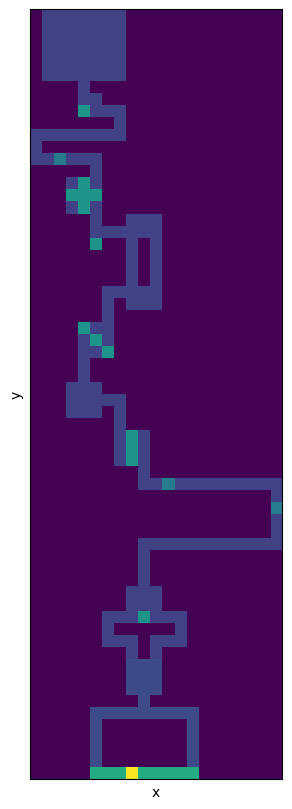

In [272]:
#PREP
local_map_0 = np.zeros((lvl0.x.max()+1,lvl0.y.max()+1)) -10
obstacles = {} # podaje kod z mapy otrzymuje obiekt obsugiwalny typu rock,prop
obj_translator = {
'["r2"]':"prop"
,'["r3"]':"prop"
, '["r1"]':"prop"
, '["g1"]':"prop"
, '["a2"]':"prop"
, '["a1"]':"prop"
, '["e1"]':"prop"
, '["n1"]':"prop"

,'["shrub_variant_1"]' :"grass"
, '["shrub_variant"]' :"grass"
    
,'["stump_variant"]':"rock"
, '["stump_variant_1"]':"rock"
}

xl = lvl0.x.max()
yl = lvl0.y.max()
for __, row in lvl0.iterrows():
    #local_map_0[row.x,row.y] = 0
    match row.state:
        case "wolny":
            local_map_0[row.x,row.y] = 0 #ciemny niebieski
        case "wolny_przygotowany":
            local_map_0[row.x,row.y] = 0  #lekki szary niebieski
        case "niedostepny":
            local_map_0[row.x,row.y] = 2 #
        
        case "zajety_ruchomy":
            #row.content_type_keys[2:-2]
            #local_map_0[row.x,row.y] = 3 #żółty
            obstacles[hash(obj_translator[row.content_type_keys]) % 37] = obj_translator[row.content_type_keys]   
            local_map_0[row.x,row.y] = hash(obj_translator[row.content_type_keys]) % 37  #na mapie jest numerek
        case "zajety_nieruchomy":
            obstacles[hash(obj_translator[row.content_type_keys]) % 37] = obj_translator[row.content_type_keys]   
            local_map_0[row.x,row.y] = hash(obj_translator[row.content_type_keys]) % 37  #na mapie jest numerek
            #local_map_0[row.x,row.y] = 4 #zielonkawy

#local_map_0[8,0] =  #INITIAL 

#lvl0.direct_neighbors_all
#plt.imshow(np.rot90(local_map_0))

start = (8,0)
local_map_0[start[0],start[1]] = 42


plt.figure(figsize=(10, 10))
plt.imshow(np.rot90(local_map_0))
plt.xticks([])
plt.yticks([])
plt.xlabel("x")
plt.ylabel("y")

plt.show()

In [228]:
np.unique(local_map_0.astype(int))

array([-10,   0,   2,  12,  17,  22,  42])

In [311]:
xl

20

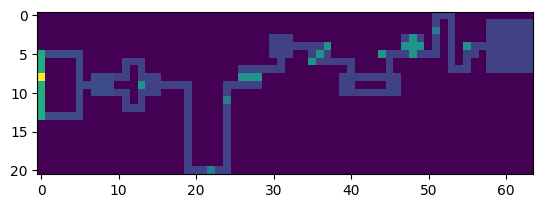

In [310]:
plt.imshow(local_map_0)

In [312]:
xl

20

In [339]:
local_map_0_dyn = local_map_0.copy()
que = deque()

visited = set()

#target = (4,55)
start = (8,0)
target = (6,0)
t = 10**7
ans = []

que.append((start[0],start[1],0,[],local_map_0_dyn)) #x,y,num,step_list,map

while que:
    print("XXX",len(que))
    q = que.popleft()
    
    if (t < q[2]):
        print("/1")
        continue
    
    if (q[0],q[1]) == target: #mamy odpowiedź
        print("####################")
        ans.append(q[3])
        t = q[2]
        print("/2")
        continue
    #memory_base.append(q[4])
    print(q[:2])

    #print(q[4][0,:])

    #(X,Y) grid
    for dirc in [(-1,0,"U"),(0,1,"R"),(0,-1,"L"),(1,0,"D")]:
        print("%",dirc[2])
        z = 0 if dirc[1] == 0 else 1 #0 oznacz suwanie gory dół

        
        #print("!!",sstep,bstep,obstacles.get(q[4][q[0]+dirc[0],q[1]+dirc[1]]))
        print(q[0]+dirc[0],q[1]+dirc[1])
        if (obstacles.get(q[4][q[0]+dirc[0],q[1]+dirc[1]]) not in ["rock"]):
                
            new_map = shift_segment(q[4], z, q[1-z],q[z], dirc[0], dirc[1]) #mapa,tryb,pos,row,col

            print("+")
            print((q[4] == new_map).sum())
            if (not np.array_equal(q[4], new_map)) and (not hash(new_map.tobytes()) in visited):
                print("++",q[0]+dirc[0],q[1]+dirc[1])
                que.append((q[0]+dirc[0],q[1]+dirc[1],q[2]+1,q[3]+[dirc[2]],new_map))
                visited.add(hash(new_map.tobytes()))
        #raise
print("!!!")
print(ans)

XXX 1
(8, 0)
% U
7 0
*|
!! [-10. -10. -10. -10. -10.  22.  22.  22.  42.  22.  22.  22.  22.  22.
 -10. -10. -10. -10. -10. -10. -10.]
5 13
move -1 0
line [-10. -10. -10. -10. -10.  22.  22.  22.  42.  22.  22.  22.  22.  22.
 -10. -10. -10. -10. -10. -10. -10.]
pos 0
l,r 5 13
segment before [22. 22. 22. 42. 22. 22. 22. 22. 22.]
segment after [22. 22. 42. 22. 22. 22. 22. 22. 22.]
+
1335
++ 7 0
% R
8 1
*|
!! [ 42. -10. -10. -10. -10.   2. -10.   2.   2.   2.   0.   0. -10.   0.
   0.   0. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.  17.  17.
  17. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.   0.   0.   0.
   0.   0.   0.   0.   0. -10. -10. -10. -10. -10. -10. -10. -10. -10.
 -10. -10. -10. -10. -10. -10. -10. -10.]
0 0
move 0 1
line [ 42. -10. -10. -10. -10.   2. -10.   2.   2.   2.   0.   0. -10.   0.
   0.   0. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.  17.  17.
  17. -10. -10. -10. -10. -10. -10. -10. -10. -10. -10.   0.   0.   0.
   0.   0.   0.   0.   0. -10. -

In [328]:
# =========================
# SEGMENT SHIFT (poprawiony)
# =========================

#//new_map = shift_segment(q[4], z, q[1-z],q[z] dirc[0], dirc[1]) #mapa,tryb,pos,rowd,cold
#mapa,0 (pionowy),0,8,-1,0

def shift_segment(grid, tryb, pos, hero, drow, dcol):
    print("*|")
    new_grid = grid.copy()

    if tryb == 0: #gora--dół
        line = new_grid[:, pos]
    else:
        line = new_grid[pos, :]
    print("!!",line)
    #raise
    ###[-10. -10. -10. -10. -10.  22.  22.  22.  42.  22.  22.  22.  22.  22. -10. -10. -10. -10. -10. -10. -10.]
    
    # znajdź -10 lewo/góra
    l = hero
    while l >= 0 and line[l] != -10:
        l -= 1
    l += 1

    # znajdź -10 prawo/dół
    r = hero
    while r < len(line) and line[r] != -10:
        r += 1
    r -= 1
    
    print(l,r)
    segment = line[l:r+1].copy()

    print("move", drow, dcol)
    print("line", line)
    print("pos", pos)
    print("l,r", l, r)
    print("segment before", segment)

    # rotacja
    if sum([drow, dcol]) > 0:
        segment = np.roll(segment, 1)
    else:
        segment = np.roll(segment, -1)

    # wklejenie
    if tryb == 0:
        new_grid[pos, l:r+1] = segment
    else:
        new_grid[l:r+1, pos] = segment
    
    print("segment after", segment)
    return new_grid

In [308]:
####
###
###
###
###
###
###
###
###

def shift_segment(grid, x, y, dx, dy):
    new_grid = grid.copy()

    if dx != 0:      # R/L
        line = new_grid[y, :]
        pos = x
        horizontal = True
    else:            # U/D
        line = new_grid[:, x]
        pos = y
        horizontal = False

    n = len(line)

    # jeśli ściana → brak ruchu
    if line[pos] == -10:
        return new_grid, (x, y)

    # =========================
    # SEGMENT = ciąg NIE -10
    # =========================
    l = pos
    while l > 0 and line[l-1] != -10:
        l -= 1

    r = pos
    while r < n-1 and line[r+1] != -10:
        r += 1

    segment = line[l:r+1].copy()

    # ❗ JEŚLI CAŁY SEGMENT JEST IDENTYCZNY → NIE MA RUCHU
    if np.all(segment == segment[0]):
        return new_grid, (x, y)

    # kierunek
    shift = 1 if (dx, dy) in [(1,0),(0,1)] else -1

    segment = np.roll(segment, shift)

    if horizontal:
        new_grid[y, l:r+1] = segment
    else:
        new_grid[l:r+1, x] = segment

    # nowa pozycja gracza
    rel = pos - l
    rel = (rel + shift) % len(segment)
    new_pos = l + rel

    return new_grid, (new_pos, y) if horizontal else (x, new_pos)

In [263]:
local_map_0_dyn[0,:]

array([-10., -10., -10., -10., -10.,  22.,  22.,  22.,  42.,  22.,  22.,
        22.,  22.,  22., -10., -10., -10., -10., -10., -10., -10.])

In [264]:
new_grid[0,:]

NameError: name 'new_grid' is not defined

In [279]:
def shift_segment(grid, x, y, dx, dy):
    new_grid = grid.copy()
    ##(8,0) (0,1)

    # 1. wybór osi
    if dx != 0:  # R / L -> wiersz
        line = new_grid[x, :]
        print("LINEEEE1",line)
        pos = y
        axis = 0
    else:        # U / D -> kolumna
        line = new_grid[:, y]
        print("LINEEEE2",line)
        pos = x
        axis = 1

    # 2. znajdź pierwsze -10 w lewo
    l = pos
    while l >= 0 and line[l] != -10:
        l -= 1

    # 3. znajdź pierwsze -10 w prawo
    r = pos
    while r < len(line) and line[r] != -10:
        r += 1

    # 4. wnętrze segmentu
    l += 1
    r -= 1

    print(l,r)
    # 5. zabezpieczenie (brak segmentu)
    if l > r:
        return new_grid, (x, y)

    segment = line[l:r+1].copy()

    # 6. rotacja
    if (dx, dy) in [(1, 0), (0, 1)]:  # R / D
        segment = np.roll(segment, 1)
    else:  # L / U
        segment = np.roll(segment, -1)

    # 7. wklejenie
    if axis == 0:
        new_grid[x, l:r+1] = segment
        new_pos = (x, y + dx)
    else:
        new_grid[l:r+1, y] = segment
        new_pos = (x + dy, y)

    return new_grid, new_pos

In [191]:
cond

63

In [184]:
z

1

In [180]:
local_map_0[7,0]

22.0

In [163]:
local_map_0[0,8]

-10.0

In [154]:
local_map_0.T[-1:,:]

array([[-10.,   0.,   0.,   0.,   0.,   0.,   0.,   0., -10., -10., -10.,
        -10., -10., -10., -10., -10., -10., -10., -10., -10., -10.]])

In [113]:
np.clip(dx,0,xl)
np.clip(dy,0,yl)

1

In [105]:
local_map_0[:,0]

array([-10., -10., -10., -10., -10.,  22.,  22.,  22.,   0.,  22.,  22.,
        22.,  22.,  22., -10., -10., -10., -10., -10., -10., -10.])

In [99]:
testmap = local_map_0 * 1

In [92]:
lvl0.loc[(lvl0.state == "zajety_nieruchomy")].sort_values(["x","y"])

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
224,5347,0.5 Dreams,zajety_nieruchomy,2,51,"[5684, 5006]","[""Shrub Variant (1)""]","[""shrub_variant_1""]"
392,5711,0.5 Dreams,zajety_nieruchomy,5,0,"[4971, 4962]","[""G1""]","[""g1""]"
585,4971,0.5 Dreams,zajety_nieruchomy,6,0,"[5514, 5711]","[""E1""]","[""e1""]"
54,5514,0.5 Dreams,zajety_nieruchomy,7,0,"[5685, 4971]","[""R3""]","[""r3""]"
563,5027,0.5 Dreams,zajety_nieruchomy,9,0,"[5548, 5685]","[""A1""]","[""a1""]"
11,5548,0.5 Dreams,zajety_nieruchomy,10,0,"[5453, 5027]","[""R2""]","[""r2""]"
151,5453,0.5 Dreams,zajety_nieruchomy,11,0,"[5697, 5548]","[""R1""]","[""r1""]"
697,4896,0.5 Dreams,zajety_nieruchomy,11,24,"[5429, 5483]","[""Shrub Variant""]","[""shrub_variant""]"
439,5697,0.5 Dreams,zajety_nieruchomy,12,0,"[5072, 5453]","[""A2""]","[""a2""]"
1052,5072,0.5 Dreams,zajety_nieruchomy,13,0,"[5697, 5775]","[""N1""]","[""n1""]"


In [93]:
lvl0.loc[(lvl0.state == "zajety_ruchomy")].sort_values(["x","y"])

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
1046,5044,0.5 Dreams,zajety_ruchomy,3,48,"[5823, 5319, 5589]","[""Stump Variant""]","[""stump_variant""]"
99,5507,0.5 Dreams,zajety_ruchomy,4,37,"[5739, 5318]","[""Stump Variant""]","[""stump_variant""]"
1036,5055,0.5 Dreams,zajety_ruchomy,4,47,"[5635, 5589, 5823]","[""Stump Variant""]","[""stump_variant""]"
288,5823,0.5 Dreams,zajety_ruchomy,4,48,"[5681, 5044, 5696, 5055]","[""Stump Variant""]","[""stump_variant""]"
440,5696,0.5 Dreams,zajety_ruchomy,4,49,"[5298, 5319, 5823]","[""Stump Variant""]","[""stump_variant""]"
603,4994,0.5 Dreams,zajety_ruchomy,4,55,"[5614, 5237]","[""Stump Variant""]","[""stump_variant""]"
418,5693,0.5 Dreams,zajety_ruchomy,5,36,"[5388, 5318, 5739, 4885]","[""Stump Variant""]","[""stump_variant""]"
936,5140,0.5 Dreams,zajety_ruchomy,5,44,[5680],"[""Stump Variant""]","[""stump_variant""]"
425,5681,0.5 Dreams,zajety_ruchomy,5,48,"[5823, 5298, 5635]","[""Stump Variant""]","[""stump_variant""]"
410,5733,0.5 Dreams,zajety_ruchomy,6,35,"[4885, 5388]","[""Stump Variant (1)""]","[""stump_variant_1""]"


In [4]:
#lvl0[lvl0.state=="niedostepny"]

In [94]:
lvl0.loc[(lvl0.y == 55) & (lvl0.x == 4)]

#start = (8,0) #x,y

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
603,4994,0.5 Dreams,zajety_ruchomy,4,55,"[5614, 5237]","[""Stump Variant""]","[""stump_variant""]"


In [73]:
#local_map_0[8,0] #(x,y) grid

0.0

In [76]:
#df.columns

In [24]:
lvl0[lvl0.content_type_keys != "[]"]

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
11,5548,0.5 Dreams,zajety_nieruchomy,10,0,"[5453, 5027]","[""R2""]","[""r2""]"
54,5514,0.5 Dreams,zajety_nieruchomy,7,0,"[5685, 4971]","[""R3""]","[""r3""]"
99,5507,0.5 Dreams,zajety_ruchomy,4,37,"[5739, 5318]","[""Stump Variant""]","[""stump_variant""]"
151,5453,0.5 Dreams,zajety_nieruchomy,11,0,"[5697, 5548]","[""R1""]","[""r1""]"
224,5347,0.5 Dreams,zajety_nieruchomy,2,51,"[5684, 5006]","[""Shrub Variant (1)""]","[""shrub_variant_1""]"
252,5311,0.5 Dreams,zajety_ruchomy,8,27,"[4910, 5160, 5190, 5268]","[""Stump Variant""]","[""stump_variant""]"
288,5823,0.5 Dreams,zajety_ruchomy,4,48,"[5681, 5044, 5696, 5055]","[""Stump Variant""]","[""stump_variant""]"
392,5711,0.5 Dreams,zajety_nieruchomy,5,0,"[4971, 4962]","[""G1""]","[""g1""]"
410,5733,0.5 Dreams,zajety_ruchomy,6,35,"[4885, 5388]","[""Stump Variant (1)""]","[""stump_variant_1""]"
418,5693,0.5 Dreams,zajety_ruchomy,5,36,"[5388, 5318, 5739, 4885]","[""Stump Variant""]","[""stump_variant""]"


In [8]:
lvl0.state.value_counts()

wolny                 128
wolny_przygotowany     48
niedostepny            27
zajety_ruchomy         14
zajety_nieruchomy      11
Name: state, dtype: int64

In [ ]:
mobj = defaultdict(list)

for _,row in lvl0.loc[lvl0.content_type_names != "[]",["x","y","content_type_keys"]].iterrows():
    mobj[row.]
    print(row)

In [196]:
lvl0.columns

Index(['node_short_id', 'level', 'state', 'x', 'y', 'direct_neighbors_all'], dtype='object')

In [5]:
df  = pd.read_csv("all_levels_slots.csv")

In [31]:
df.iloc[:,0]#.str.split()[1]

0        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
1        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
2        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
3        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
4        E:\AssetRipper_win_x64\Export\AssetRipper_expo...
                               ...                        
17063    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17064    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17065    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17066    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
17067    E:\AssetRipper_win_x64\Export\AssetRipper_expo...
Name: slot_id, Length: 17068, dtype: object

In [51]:
df.slot_id.transform(lambda x:x.str.split("\\")[-1].split(".unity#")[0])

ValueError: Transform function failed

In [50]:
df.slot_id[0].split("\\")[-1].split(".unity#")[0]

'0.5 Dreams'

In [52]:
s=set()
for l in df.slot_id:
    s.add(l.split("\\")[-1].split(".unity#")[0])

In [53]:
s

{'0.5 Dreams',
 '1 Town1',
 '11 Town5',
 '2 Wild 1',
 '3 Hurveth',
 '4 Wild 2',
 '5 Town2',
 '6 Wild 3',
 '8 Town4'}

In [7]:
from arranger_bfs import build_solver

allowed_ids = lvl0["node_short_id"].astype(str).tolist()
solver = build_solver(
    "dreams_types_nodes.csv",
    level="0.5 Dreams",
    allowed_ids=allowed_ids,
)

result = solver.solve_xy((7, 63), (5, 5),max_states=20000)
#space=world
#result = solver.solve(start_id="5562", goal_id="5290", max_states=200000)

print(result["moves"])
print(result["states"][:5])

RuntimeError: BFS exceeded max_states=20000.

In [6]:
lvl0.loc[(lvl0.x == 7) & (lvl0.y == 63)]

,node_short_id,level,state,x,y,direct_neighbors_all,content_type_names,content_type_keys
161,5402,0.5 Dreams,wolny,7,63,"[5756, 4944]",[],[]
